## 1. Import Libraries

In [73]:
import numpy as np

import pandas as pd

import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
	OneHotEncoder,
	OrdinalEncoder,
	StandardScaler,
	MinMaxScaler,
	PowerTransformer,
	FunctionTransformer
)

from feature_engine.outliers import Winsorizer
from feature_engine.datetime import DatetimeFeatures
from feature_engine.selection import SelectBySingleFeaturePerformance
from feature_engine.encoding import (
	RareLabelEncoder,
	MeanEncoder,
	CountFrequencyEncoder
)

import matplotlib.pyplot as plt

import warnings

## 2. Display Settings

In [16]:
pd.set_option("display.max_columns", None) # Force pandas to show every column

In [17]:
sklearn.set_config(transform_output="pandas") # by default scikitlearn transformers return numpy arrays - by this it will return pd dataframes

In [18]:
warnings.filterwarnings("ignore")

## 3. Read the Data

In [19]:
# NOTE - We do Feature Engineering only on the training data. All the transformations on other subsets

In [20]:
path = r"C:\Users\ashis\OneDrive\Desktop\flights-sagemaker-project\data\train.csv"

train = pd.read_csv(path)

train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Indigo,2019-05-27,Mumbai,Hyderabad,02:35:00,04:05:00,90,0.0,No info,2754
1,Jet Airways,2019-06-09,Delhi,Cochin,14:00:00,12:35:00,1355,1.0,In-flight meal not included,10262
2,Spicejet,2019-05-06,Chennai,Kolkata,08:20:00,10:35:00,135,0.0,No check-in baggage included,3859
3,Air India,2019-05-24,Kolkata,Banglore,14:35:00,14:35:00,1440,1.0,No info,6528
4,Vistara,2019-03-12,Mumbai,Hyderabad,07:30:00,19:55:00,745,1.0,No info,12080
...,...,...,...,...,...,...,...,...,...,...
635,Indigo,2019-03-06,Delhi,Cochin,06:40:00,12:00:00,320,1.0,No info,5647
636,Jet Airways,2019-03-18,Banglore,New Delhi,16:55:00,23:00:00,365,1.0,No info,13555
637,Indigo,2019-03-06,Delhi,Cochin,07:30:00,21:00:00,810,1.0,No info,14871
638,Air Asia,2019-06-15,Banglore,Delhi,04:55:00,07:45:00,170,0.0,No info,4282


In [21]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          640 non-null    object 
 1   date_of_journey  640 non-null    object 
 2   source           640 non-null    object 
 3   destination      640 non-null    object 
 4   dep_time         640 non-null    object 
 5   arrival_time     640 non-null    object 
 6   duration         640 non-null    int64  
 7   total_stops      640 non-null    float64
 8   additional_info  640 non-null    object 
 9   price            640 non-null    int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 50.1+ KB


In [22]:
X_train = train.drop(columns="price")
y_train = train.price.copy()

## 4. Transformation Operations (column-wise)

In [23]:
X_train.columns.to_list()

['airline',
 'date_of_journey',
 'source',
 'destination',
 'dep_time',
 'arrival_time',
 'duration',
 'total_stops',
 'additional_info']

### 4.1 airline

In [24]:
X_train.airline

0                 Indigo
1            Jet Airways
2               Spicejet
3              Air India
4                Vistara
             ...        
635               Indigo
636          Jet Airways
637               Indigo
638             Air Asia
639    Multiple Carriers
Name: airline, Length: 640, dtype: object

In [25]:
# For Airline - 1st we impute any missing values then we group the rare values as others and encode using one-hot encoding

air_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("grouper", RareLabelEncoder(tol=0.1, replace_with="Other", n_categories=2)),  # all the categories that occur <10% grouped together
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])  

air_transformer.fit_transform(X_train.loc[:, ["airline"]])#.airline.value_counts()

,airline_Air India,airline_Indigo,airline_Jet Airways,airline_Multiple Carriers,airline_Other
0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
635,0.0,1.0,0.0,0.0,0.0
636,0.0,0.0,1.0,0.0,0.0
637,0.0,1.0,0.0,0.0,0.0
638,0.0,0.0,0.0,0.0,1.0


### 4.2 date_of_journey

In [26]:
X_train.date_of_journey

0      2019-05-27
1      2019-06-09
2      2019-05-06
3      2019-05-24
4      2019-03-12
          ...    
635    2019-03-06
636    2019-03-18
637    2019-03-06
638    2019-06-15
639    2019-04-24
Name: date_of_journey, Length: 640, dtype: object

In [27]:
# We'll extract Date-Time features from it and then perform Min-Max Scaling

In [28]:
feature_to_extract = ["month", "week", "day_of_week", "day_of_year"]

doj_transformer = Pipeline(steps=[
    ("dt", DatetimeFeatures(features_to_extract=feature_to_extract, yearfirst=True, format="mixed")),
    ("scaler", MinMaxScaler())
])

doj_transformer.fit_transform(X_train.loc[:, ["date_of_journey"]])

,date_of_journey_month,date_of_journey_week,date_of_journey_day_of_week,date_of_journey_day_of_year
0,0.666667,0.764706,0.000000,0.737288
1,1.000000,0.823529,1.000000,0.847458
2,0.666667,0.588235,0.000000,0.559322
3,0.666667,0.705882,0.666667,0.711864
4,0.000000,0.117647,0.166667,0.093220
...,...,...,...,...
635,0.000000,0.058824,0.333333,0.042373
636,0.000000,0.176471,0.000000,0.144068
637,0.000000,0.058824,0.333333,0.042373
638,1.000000,0.882353,0.833333,0.898305


### 4.3 source & destination

In [30]:
X_train.source

0        Mumbai
1         Delhi
2       Chennai
3       Kolkata
4        Mumbai
         ...   
635       Delhi
636    Banglore
637       Delhi
638    Banglore
639       Delhi
Name: source, Length: 640, dtype: object

In [31]:
X_train.destination

0      Hyderabad
1         Cochin
2        Kolkata
3       Banglore
4      Hyderabad
         ...    
635       Cochin
636    New Delhi
637       Cochin
638        Delhi
639       Cochin
Name: destination, Length: 640, dtype: object

In [ ]:
# For source & destination - we group the rare labels as we saw in eda
# Mean encoder - Each categorical value is replaced by mean of targe variable for that category
# Power Transformer - To convert transformed variable as symmetric as possible

In [ ]:
location_subset = X_train.loc[:, ["source", "destination"]]
location_subset

,source,destination
0,Mumbai,Hyderabad
1,Delhi,Cochin
2,Chennai,Kolkata
3,Kolkata,Banglore
4,Mumbai,Hyderabad
...,...,...
635,Delhi,Cochin
636,Banglore,New Delhi
637,Delhi,Cochin
638,Banglore,Delhi


In [40]:
location_pipe1 = Pipeline(steps=[
    ("grouper", RareLabelEncoder(tol=0.1, replace_with="Other", n_categories=2)),
    ("encoder", MeanEncoder()),
    ("scaler", PowerTransformer())
])

location_pipe1.fit_transform(location_subset, y_train)

,source,destination
0,-1.733315,-0.896986
1,1.017318,1.016590
2,-1.733315,-0.896986
3,-0.173628,-0.202507
4,-1.733315,-0.896986
...,...,...
635,1.017318,1.016590
636,-0.950496,-0.896986
637,1.017318,1.016590
638,-0.950496,-1.825762


In [41]:
np.union1d(
    X_train.source.unique(),
    X_train.destination.unique()
)

array(['Banglore', 'Chennai', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata',
       'Mumbai', 'New Delhi'], dtype=object)

In [48]:
def is_north(X):
    columns = X.columns.to_list()
    north_cities = ["Delhi", "Kolkata", "Mumbai", "New Delhi"]
    return (
        X
        .assign(**{
            f"{col}_is_north": X.loc[:, col].isin(north_cities).astype(int)
            for col in columns
        })
        .drop(columns=columns)
    )

FunctionTransformer(func=is_north).fit_transform(location_subset)

,source_is_north,destination_is_north
0,1,0
1,1,0
2,0,1
3,1,0
4,1,0
...,...,...
635,1,0
636,0,1
637,1,0
638,0,1


In [50]:
location_transformer = FeatureUnion(transformer_list=[
    ("part1", location_pipe1),
    ("part2", FunctionTransformer(func=is_north))
])

location_transformer.fit_transform(location_subset, y_train)

,source,destination,source_is_north,destination_is_north
0,-1.733315,-0.896986,1,0
1,1.017318,1.016590,1,0
2,-1.733315,-0.896986,0,1
3,-0.173628,-0.202507,1,0
4,-1.733315,-0.896986,1,0
...,...,...,...,...
635,1.017318,1.016590,1,0
636,-0.950496,-0.896986,0,1
637,1.017318,1.016590,1,0
638,-0.950496,-1.825762,0,1


### 4.4 dep_time & arrival_time

In [52]:
X_train.dep_time

0      02:35:00
1      14:00:00
2      08:20:00
3      14:35:00
4      07:30:00
         ...   
635    06:40:00
636    16:55:00
637    07:30:00
638    04:55:00
639    07:10:00
Name: dep_time, Length: 640, dtype: object

In [53]:
X_train.arrival_time

0      04:05:00
1      12:35:00
2      10:35:00
3      14:35:00
4      19:55:00
         ...   
635    12:00:00
636    23:00:00
637    21:00:00
638    07:45:00
639    16:10:00
Name: arrival_time, Length: 640, dtype: object

In [ ]:
# We can observe from above that all seconds values are zeros

In [54]:
time_subset = X_train.loc[:, ["dep_time", "arrival_time"]]
time_subset

,dep_time,arrival_time
0,02:35:00,04:05:00
1,14:00:00,12:35:00
2,08:20:00,10:35:00
3,14:35:00,14:35:00
4,07:30:00,19:55:00
...,...,...
635,06:40:00,12:00:00
636,16:55:00,23:00:00
637,07:30:00,21:00:00
638,04:55:00,07:45:00


In [56]:
time_pipe1 = Pipeline(steps=[
    ("dt", DatetimeFeatures(features_to_extract=["hour", "minute"])),
    ("scaler", MinMaxScaler())
])

time_pipe1.fit_transform(time_subset)

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute
0,0.045455,0.636364,0.173913,0.090909
1,0.590909,0.000000,0.521739,0.636364
2,0.318182,0.363636,0.434783,0.636364
3,0.590909,0.636364,0.608696,0.636364
4,0.272727,0.545455,0.826087,1.000000
...,...,...,...,...
635,0.227273,0.727273,0.521739,0.000000
636,0.681818,1.000000,1.000000,0.000000
637,0.272727,0.545455,0.913043,0.000000
638,0.136364,1.000000,0.304348,0.818182


In [58]:
# Creating new feature - morning, afternoon, night from hour value

def part_of_day(X, morning=4, noon=12, eve=16, night=20):
    columns = X.columns.to_list()
    X_temp = X.assign(**{
        col: pd.to_datetime(X.loc[:, col]).dt.hour
        for col in columns
    })

    return(
        X_temp
        .assign(**{
            f"{col}_part_of_day": np.select(
                [X_temp.loc[:, col].between(morning, noon, inclusive="left"),
                X_temp.loc[:, col].between(noon, eve, inclusive="left"),
                X_temp.loc[:, col].between(eve, night, inclusive="left")],
                ["morning", "afternoon", "evening"],
                default="night"    
            )
            for col in columns
        })
    )


FunctionTransformer(func=part_of_day).fit_transform(time_subset)

,dep_time,arrival_time,dep_time_part_of_day,arrival_time_part_of_day
0,2,4,night,morning
1,14,12,afternoon,afternoon
2,8,10,morning,morning
3,14,14,afternoon,afternoon
4,7,19,morning,evening
...,...,...,...,...
635,6,12,morning,afternoon
636,16,23,evening,night
637,7,21,morning,night
638,4,7,morning,morning


In [61]:
time_pipe2 = Pipeline(steps=[
    ("part", FunctionTransformer(func=part_of_day)),
    ("encoder", CountFrequencyEncoder()),
    ("scaler", MinMaxScaler())
])

time_pipe2.fit_transform(time_subset)

,dep_time,arrival_time,dep_time_part_of_day,arrival_time_part_of_day
0,0.045455,0.173913,0.120930,1.000000
1,0.590909,0.521739,0.000000,0.000000
2,0.318182,0.434783,1.000000,1.000000
3,0.590909,0.608696,0.000000,0.000000
4,0.272727,0.826087,1.000000,0.516129
...,...,...,...,...
635,0.227273,0.521739,1.000000,0.000000
636,0.681818,1.000000,0.144186,0.806452
637,0.272727,0.913043,1.000000,0.806452
638,0.136364,0.304348,1.000000,1.000000


In [62]:
time_transformer = FeatureUnion(transformer_list=[
    ("part1", time_pipe1),
    ("part2", time_pipe2)
])

time_transformer.fit_transform(time_subset)

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute,dep_time,arrival_time,dep_time_part_of_day,arrival_time_part_of_day
0,0.045455,0.636364,0.173913,0.090909,0.045455,0.173913,0.120930,1.000000
1,0.590909,0.000000,0.521739,0.636364,0.590909,0.521739,0.000000,0.000000
2,0.318182,0.363636,0.434783,0.636364,0.318182,0.434783,1.000000,1.000000
3,0.590909,0.636364,0.608696,0.636364,0.590909,0.608696,0.000000,0.000000
4,0.272727,0.545455,0.826087,1.000000,0.272727,0.826087,1.000000,0.516129
...,...,...,...,...,...,...,...,...
635,0.227273,0.727273,0.521739,0.000000,0.227273,0.521739,1.000000,0.000000
636,0.681818,1.000000,1.000000,0.000000,0.681818,1.000000,0.144186,0.806452
637,0.272727,0.545455,0.913043,0.000000,0.272727,0.913043,1.000000,0.806452
638,0.136364,1.000000,0.304348,0.818182,0.136364,0.304348,1.000000,1.000000


### 4.5 duration

In [64]:
X_train.duration

0        90
1      1355
2       135
3      1440
4       745
       ... 
635     320
636     365
637     810
638     170
639     540
Name: duration, Length: 640, dtype: int64

In [65]:
# We'll handle the extreme values
# We'll handle the missing values by imputation
# Then we'll apply 4 different transformers

In [66]:
# Duration categories - (<180 mins - short, 180-400 mins - medium, >400 mins. - large)
# Ordinal encoding

In [ ]:
# RBF Kernel is used to check how close are two values - input & reference

In [69]:

(
	X_train
	.duration
	.quantile([0.25, 0.5, 0.75])
	.values
	.reshape(-1, 1)
	# .shape
)

array([[170.  ],
       [505.  ],
       [861.25]])

In [70]:

class RBFPercentileSimilarity(BaseEstimator, TransformerMixin):
	def __init__(self, variables=None, percentiles=[0.25, 0.5, 0.75], gamma=0.1):
		self.variables = variables
		self.percentiles = percentiles
		self.gamma = gamma


	def fit(self, X, y=None):
		if not self.variables:
			self.variables = X.select_dtypes(include="number").columns.to_list()

		self.reference_values_ = {
			col: (
				X
				.loc[:, col]
				.quantile(self.percentiles)
				.values
				.reshape(-1, 1)
			)
			for col in self.variables
		}

		return self


	def transform(self, X):
		objects = []
		for col in self.variables:
			columns = [f"{col}_rbf_{int(percentile * 100)}" for percentile in self.percentiles]
			obj = pd.DataFrame(
				data=rbf_kernel(X.loc[:, [col]], Y=self.reference_values_[col], gamma=self.gamma),
				columns=columns
			)
			objects.append(obj)
		return pd.concat(objects, axis=1)

In [71]:
RBFPercentileSimilarity(percentiles=[0.25, 0.5, 0.75]).fit_transform(X_train)


,duration_rbf_25,duration_rbf_50,duration_rbf_75,total_stops_rbf_25,total_stops_rbf_50,total_stops_rbf_75
0,1.125982e-278,0.000000e+00,0.000000e+00,1.000000,0.904837,0.904837
1,0.000000e+00,0.000000e+00,0.000000e+00,0.904837,1.000000,1.000000
2,6.293989e-54,0.000000e+00,0.000000e+00,1.000000,0.904837,0.904837
3,0.000000e+00,0.000000e+00,0.000000e+00,0.904837,1.000000,1.000000
4,0.000000e+00,0.000000e+00,0.000000e+00,0.904837,1.000000,1.000000
...,...,...,...,...,...,...
635,0.000000e+00,0.000000e+00,0.000000e+00,0.904837,1.000000,1.000000
636,0.000000e+00,0.000000e+00,0.000000e+00,0.904837,1.000000,1.000000
637,0.000000e+00,0.000000e+00,8.508245e-115,0.904837,1.000000,1.000000
638,1.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.904837,0.904837


In [74]:
def duration_category(X, short=180, med=400):
	return (
		X
		.assign(duration_cat=np.select([X.duration.lt(short),
									    X.duration.between(short, med, inclusive="left")],
									   ["short", "medium"],
									   default="long"))
		.drop(columns="duration")
	)

In [75]:
def is_over(X, value=1000):
	return (
		X
		.assign(**{
			f"duration_over_{value}": X.duration.ge(value).astype(int)
		})
		.drop(columns="duration")
	)

In [76]:
duration_pipe1 = Pipeline(steps=[
	("rbf", RBFPercentileSimilarity()),
	("scaler", PowerTransformer())
])

duration_pipe2 = Pipeline(steps=[
	("cat", FunctionTransformer(func=duration_category)),
	("encoder", OrdinalEncoder(categories=[["short", "medium", "long"]]))
])

duration_union = FeatureUnion(transformer_list=[
	("part1", duration_pipe1),
	("part2", duration_pipe2),
	("part3", FunctionTransformer(func=is_over)),
	("part4", StandardScaler())
])

duration_transformer = Pipeline(steps=[
	("outliers", Winsorizer(capping_method="iqr", fold=1.5)),
	("imputer", SimpleImputer(strategy="median")),
	("union", duration_union)
])

duration_transformer.fit_transform(X_train.loc[:, ["duration"]])

,duration_rbf_25,duration_rbf_50,duration_rbf_75,duration_cat,duration_over_1000,duration
0,-0.339906,-0.105235,-0.105099,0.0,0,-1.115134
1,-0.339906,-0.105235,-0.105099,2.0,1,1.623213
2,-0.339906,-0.105235,-0.105099,0.0,0,-1.017722
3,-0.339906,-0.105235,-0.105099,2.0,1,1.807212
4,-0.339906,-0.105235,-0.105099,2.0,0,0.302745
...,...,...,...,...,...,...
635,-0.339906,-0.105235,-0.105099,1.0,0,-0.617253
636,-0.339906,-0.105235,-0.105099,1.0,0,-0.519841
637,-0.339906,-0.105235,-0.105099,2.0,0,0.443451
638,3.248912,-0.105235,-0.105099,0.0,0,-0.941958


### 4.6 total_stops

In [77]:
X_train.total_stops

0      0.0
1      1.0
2      0.0
3      1.0
4      1.0
      ... 
635    1.0
636    1.0
637    1.0
638    0.0
639    1.0
Name: total_stops, Length: 640, dtype: float64

In [78]:
def is_direct(X):
	return X.assign(is_direct_flight=X.total_stops.eq(0).astype(int))


total_stops_transformer = Pipeline(steps=[
	("imputer", SimpleImputer(strategy="most_frequent")),
	("", FunctionTransformer(func=is_direct))
])

total_stops_transformer.fit_transform(X_train.loc[:, ["total_stops"]])

,total_stops,is_direct_flight
0,0.0,1
1,1.0,0
2,0.0,1
3,1.0,0
4,1.0,0
...,...,...
635,1.0,0
636,1.0,0
637,1.0,0
638,0.0,1


### 4.7 additional_info

In [79]:

X_train.additional_info

0                           No info
1       In-flight meal not included
2      No check-in baggage included
3                           No info
4                           No info
                   ...             
635                         No info
636                         No info
637                         No info
638                         No info
639     In-flight meal not included
Name: additional_info, Length: 640, dtype: object

In [80]:
info_pipe1 = Pipeline(steps=[
	("group", RareLabelEncoder(tol=0.1, n_categories=2, replace_with="Other")),
	("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

info_pipe1.fit_transform(X_train.loc[:, ["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No info,additional_info_Other
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
635,0.0,1.0,0.0
636,0.0,1.0,0.0
637,0.0,1.0,0.0
638,0.0,1.0,0.0


In [81]:
def have_info(X):
	return X.assign(additional_info=X.additional_info.ne("No Info").astype(int))

In [82]:
info_union = FeatureUnion(transformer_list=[
	("part1", info_pipe1),
	("part2", FunctionTransformer(func=have_info))
])

In [83]:

info_transformer = Pipeline(steps=[
	("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
	("union", info_union)
])

info_transformer.fit_transform(X_train.loc[:, ["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No info,additional_info_Other,additional_info
0,0.0,1.0,0.0,1
1,1.0,0.0,0.0,1
2,0.0,0.0,1.0,1
3,0.0,1.0,0.0,1
4,0.0,1.0,0.0,1
...,...,...,...,...
635,0.0,1.0,0.0,1
636,0.0,1.0,0.0,1
637,0.0,1.0,0.0,1
638,0.0,1.0,0.0,1


### 4.8 Column Transformer

In [90]:

column_transformer = ColumnTransformer(transformers=[
	("air", air_transformer, ["airline"]),
	("doj", doj_transformer, ["date_of_journey"]),
	("location", location_transformer, ["source", 'destination']),
	("time", time_transformer, ["dep_time", "arrival_time"]),
	("dur", duration_transformer, ["duration"]),
	("stops", total_stops_transformer, ["total_stops"]),
	("info", info_transformer, ["additional_info"])
], remainder="passthrough")

column_transformer.fit_transform(X_train, y_train)

,air__airline_Air India,air__airline_Indigo,air__airline_Jet Airways,air__airline_Multiple Carriers,air__airline_Other,doj__date_of_journey_month,doj__date_of_journey_week,doj__date_of_journey_day_of_week,doj__date_of_journey_day_of_year,location__source,location__destination,location__source_is_north,location__destination_is_north,time__dep_time_hour,time__dep_time_minute,time__arrival_time_hour,time__arrival_time_minute,time__dep_time,time__arrival_time,time__dep_time_part_of_day,time__arrival_time_part_of_day,dur__duration_rbf_25,dur__duration_rbf_50,dur__duration_rbf_75,dur__duration_cat,dur__duration_over_1000,dur__duration,stops__total_stops,stops__is_direct_flight,info__additional_info_In-flight meal not included,info__additional_info_No info,info__additional_info_Other,info__additional_info
0,0.0,1.0,0.0,0.0,0.0,0.666667,0.764706,0.000000,0.737288,-1.733315,-0.896986,1,0,0.045455,0.636364,0.173913,0.090909,0.045455,0.173913,0.120930,1.000000,-0.339906,-0.105235,-0.105099,0.0,0,-1.115134,0.0,1,0.0,1.0,0.0,1
1,0.0,0.0,1.0,0.0,0.0,1.000000,0.823529,1.000000,0.847458,1.017318,1.016590,1,0,0.590909,0.000000,0.521739,0.636364,0.590909,0.521739,0.000000,0.000000,-0.339906,-0.105235,-0.105099,2.0,1,1.623213,1.0,0,1.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,1.0,0.666667,0.588235,0.000000,0.559322,-1.733315,-0.896986,0,1,0.318182,0.363636,0.434783,0.636364,0.318182,0.434783,1.000000,1.000000,-0.339906,-0.105235,-0.105099,0.0,0,-1.017722,0.0,1,0.0,0.0,1.0,1
3,1.0,0.0,0.0,0.0,0.0,0.666667,0.705882,0.666667,0.711864,-0.173628,-0.202507,1,0,0.590909,0.636364,0.608696,0.636364,0.590909,0.608696,0.000000,0.000000,-0.339906,-0.105235,-0.105099,2.0,1,1.807212,1.0,0,0.0,1.0,0.0,1
4,0.0,0.0,0.0,0.0,1.0,0.000000,0.117647,0.166667,0.093220,-1.733315,-0.896986,1,0,0.272727,0.545455,0.826087,1.000000,0.272727,0.826087,1.000000,0.516129,-0.339906,-0.105235,-0.105099,2.0,0,0.302745,1.0,0,0.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,0.0,1.0,0.0,0.0,0.0,0.000000,0.058824,0.333333,0.042373,1.017318,1.016590,1,0,0.227273,0.727273,0.521739,0.000000,0.227273,0.521739,1.000000,0.000000,-0.339906,-0.105235,-0.105099,1.0,0,-0.617253,1.0,0,0.0,1.0,0.0,1
636,0.0,0.0,1.0,0.0,0.0,0.000000,0.176471,0.000000,0.144068,-0.950496,-0.896986,0,1,0.681818,1.000000,1.000000,0.000000,0.681818,1.000000,0.144186,0.806452,-0.339906,-0.105235,-0.105099,1.0,0,-0.519841,1.0,0,0.0,1.0,0.0,1
637,0.0,1.0,0.0,0.0,0.0,0.000000,0.058824,0.333333,0.042373,1.017318,1.016590,1,0,0.272727,0.545455,0.913043,0.000000,0.272727,0.913043,1.000000,0.806452,-0.339906,-0.105235,-0.105099,2.0,0,0.443451,1.0,0,0.0,1.0,0.0,1
638,0.0,0.0,0.0,0.0,1.0,1.000000,0.882353,0.833333,0.898305,-0.950496,-1.825762,0,1,0.136364,1.000000,0.304348,0.818182,0.136364,0.304348,1.000000,1.000000,3.248912,-0.105235,-0.105099,0.0,0,-0.941958,0.0,1,0.0,1.0,0.0,1


## 5. Feature Selection

In [85]:

estimator = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=42)

selector = SelectBySingleFeaturePerformance(
	estimator=estimator,
	scoring="r2",
	threshold=0.1
) 

## 6. Putting it all Together

In [86]:

preprocessor = Pipeline(steps=[
	("ct", column_transformer),
	("selector", selector)
])

preprocessor.fit_transform(X_train, y_train)


,air__airline_Jet Airways,air__airline_Other,doj__date_of_journey_month,doj__date_of_journey_week,doj__date_of_journey_day_of_year,location__source,location__destination,dur__duration_rbf_25,dur__duration_cat,dur__duration,stops__total_stops,stops__is_direct_flight
0,0.0,0.0,0.666667,0.764706,0.737288,-1.733315,-0.896986,-0.339906,0.0,-1.115134,0.0,1
1,1.0,0.0,1.000000,0.823529,0.847458,1.017318,1.016590,-0.339906,2.0,1.623213,1.0,0
2,0.0,1.0,0.666667,0.588235,0.559322,-1.733315,-0.896986,-0.339906,0.0,-1.017722,0.0,1
3,0.0,0.0,0.666667,0.705882,0.711864,-0.173628,-0.202507,-0.339906,2.0,1.807212,1.0,0
4,0.0,1.0,0.000000,0.117647,0.093220,-1.733315,-0.896986,-0.339906,2.0,0.302745,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
635,0.0,0.0,0.000000,0.058824,0.042373,1.017318,1.016590,-0.339906,1.0,-0.617253,1.0,0
636,1.0,0.0,0.000000,0.176471,0.144068,-0.950496,-0.896986,-0.339906,1.0,-0.519841,1.0,0
637,0.0,0.0,0.000000,0.058824,0.042373,1.017318,1.016590,-0.339906,2.0,0.443451,1.0,0
638,0.0,1.0,1.000000,0.882353,0.898305,-0.950496,-1.825762,3.248912,0.0,-0.941958,0.0,1


In [91]:
preprocessor

,steps,"[('ct', ...), ('selector', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('air', ...), ('doj', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 7. Visualizations

In [87]:
feature_performances = preprocessor.named_steps["selector"].feature_performance_
feature_performances

{'air__airline_Air India': np.float64(-0.017671642775092256),
 'air__airline_Indigo': np.float64(0.09543254744983032),
 'air__airline_Jet Airways': np.float64(0.178771329286889),
 'air__airline_Multiple Carriers': np.float64(0.01290651207031627),
 'air__airline_Other': np.float64(0.1167415903793626),
 'doj__date_of_journey_month': np.float64(0.10411568259126673),
 'doj__date_of_journey_week': np.float64(0.15056378964681785),
 'doj__date_of_journey_day_of_week': np.float64(-0.04441854451991315),
 'doj__date_of_journey_day_of_year': np.float64(0.1261783544365107),
 'location__source': np.float64(0.10443667256995208),
 'location__destination': np.float64(0.1138283179101333),
 'location__source_is_north': np.float64(0.028274158138001344),
 'location__destination_is_north': np.float64(0.028274158138001344),
 'time__dep_time_hour': np.float64(-0.022961722383518717),
 'time__dep_time_minute': np.float64(0.03818890744130458),
 'time__arrival_time_hour': np.float64(0.05120981596573552),
 'time_

In [88]:

sorted_feat_imp = dict(sorted(feature_performances.items(), key=lambda val: val[1]))
sorted_feat_imp

{'doj__date_of_journey_day_of_week': np.float64(-0.04441854451991315),
 'dur__duration_rbf_50': np.float64(-0.028457107138941302),
 'time__dep_time_hour': np.float64(-0.022961722383518717),
 'time__dep_time': np.float64(-0.022961722383518717),
 'time__dep_time_part_of_day': np.float64(-0.019037526339794015),
 'air__airline_Air India': np.float64(-0.017671642775092256),
 'info__additional_info_In-flight meal not included': np.float64(-0.017463868707626062),
 'dur__duration_rbf_75': np.float64(-0.014234530242278684),
 'info__additional_info_No info': np.float64(-0.014044848167832765),
 'info__additional_info': np.float64(-0.012270587028007984),
 'time__arrival_time_part_of_day': np.float64(0.0008914336530412292),
 'time__arrival_time_minute': np.float64(0.00337500923177092),
 'air__airline_Multiple Carriers': np.float64(0.01290651207031627),
 'info__additional_info_Other': np.float64(0.02656346095255857),
 'location__source_is_north': np.float64(0.028274158138001344),
 'location__destina

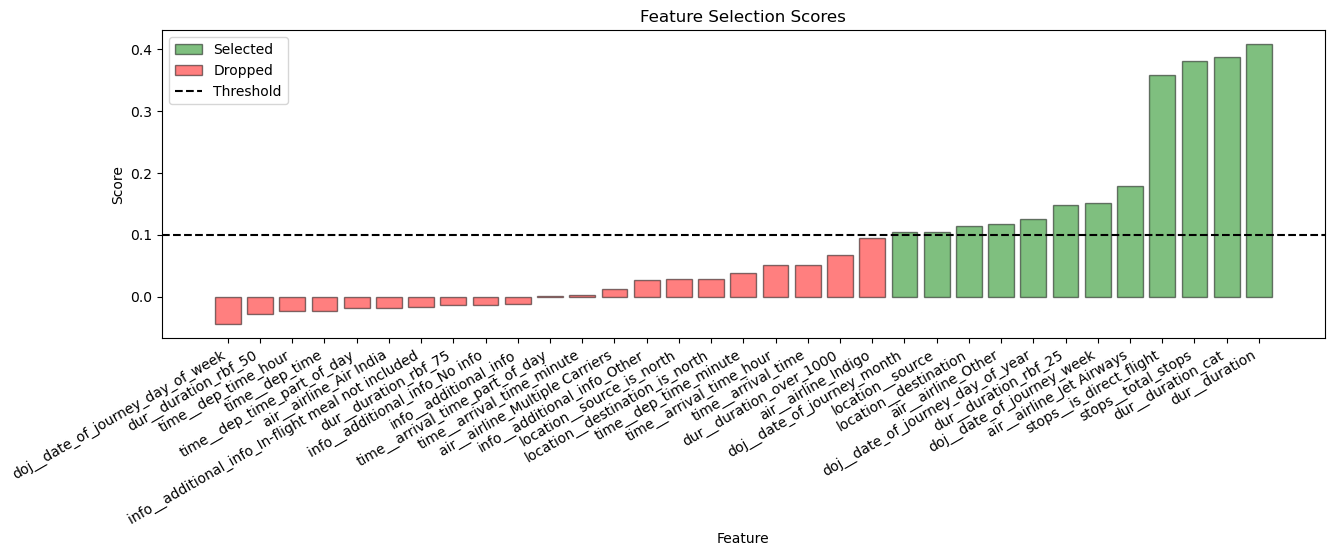

In [89]:

THRESHOLD = 0.1

selected_bar = None
dropped_bar = None
colors = ["red" if score < THRESHOLD else "green" for score in sorted_feat_imp.values()]


fig, ax = plt.subplots(figsize=(15, 4)) 

for i, (feature, score) in enumerate(sorted_feat_imp.items()):
	params = dict(
		x=i,
		height=score,
		edgecolor="black",
		alpha=0.5
	)
	
	if score < THRESHOLD:
		bar = ax.bar(
			color="red",
			**params
		)
		if not dropped_bar:
			dropped_bar = bar[0]
	else:
		bar = ax.bar(
			color="green",
			**params
		)
		if not selected_bar:
			selected_bar = bar[0]

thresh_line = ax.axhline(
	y=0.1,
	color="black",
	linestyle="--"
)

ax.set_xticks(
	ticks=range(len(sorted_feat_imp)),
	labels=list(sorted_feat_imp.keys()),
	rotation=30,
	ha="right"
)

ax.set(
	xlabel="Feature",
	ylabel="Score",
	title="Feature Selection Scores"
)

ax.legend(
	handles=[selected_bar, dropped_bar, thresh_line],
	labels=["Selected", "Dropped", "Threshold"],
	loc="upper left"
)

plt.show()

- The dataset went upto 31 columns after Feature Engineering
- The Feature Selection algorithm selected 13 features out of that